# Teen Social Media Mental Health Supervised Machine Learning Predictive Model

## Problem Statement:The objective of this project is to develop a Machine Learning classification model that predicts whether a student is likely to experience depression (depression_label) based on factors such as age, gender, social media usage patterns, sleep habits, screen time before sleep, academic performance, physical activity, social interaction level, stress level, anxiety level, and addiction level. By analyzing these behavioral, lifestyle, and psychological indicators, the model aims to identify students who may be at risk of depression, enabling early intervention and support.

In [123]:
import pandas as pd
import numpy as np
Teen_Mental_Health_Dataset=pd.read_csv("C:/Users/abrau/ML Projects/Python IVY Feb-2024-20260611T164017Z-3-001/Python IVY Feb-2024/My ML Projects/Classification Projects/Teen Mental Health/Teen_Mental_Health_Dataset.csv",
                            encoding='latin')
print('Data Before deleting duplicate values:',Teen_Mental_Health_Dataset.shape)  
Teen_Mental_Health_Dataset.drop_duplicates(inplace=True)
print('Data After:deleting duplicate values',Teen_Mental_Health_Dataset.shape)
pd.set_option('display.max_rows',None) 
pd.set_option('display.max_columns',None)  
Teen_Mental_Health_Dataset.head(30)

Data Before deleting duplicate values: (1200, 13)
Data After:deleting duplicate values (1200, 13)


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0
8,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,high,1,10,9,0
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0


In [124]:
pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

### Target Variable:depression_label

## Exploratory Data Analysis

<Axes: xlabel='depression_label'>

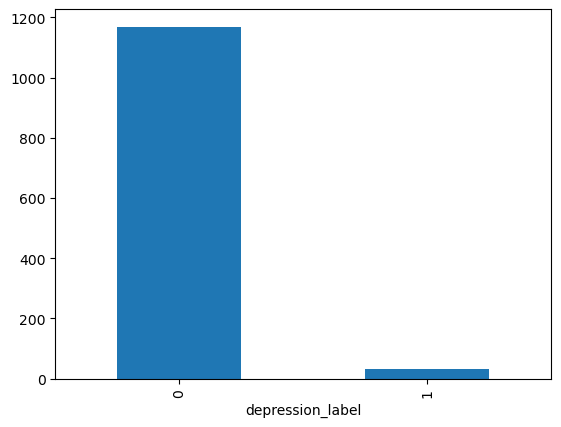

In [125]:
Teen_Mental_Health_Dataset.groupby('depression_label').size().plot(kind='bar')

In [126]:
Teen_Mental_Health_Dataset.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [127]:
Teen_Mental_Health_Dataset.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [128]:
Teen_Mental_Health_Dataset.nunique()

age                           7
gender                        2
daily_social_media_hours     71
platform_usage                3
sleep_hours                  51
screen_time_before_sleep     26
academic_performance        201
physical_activity            21
social_interaction_level      3
stress_level                 10
anxiety_level                10
addiction_level              10
depression_label              2
dtype: int64

### CategoricalCols=['age', 'gender','platform_usage','social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']
### ContinousCols=['daily_social_media_hours','sleep_hours','academic_performance','physical_activity','screen_time_before_sleep']

In [129]:
Teen_Mental_Health_Dataset.shape

(1200, 13)

In [130]:
Teen_Mental_Health_Dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [131]:
Teen_Mental_Health_Dataset.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


## Uni Variate Analysis by Bar Charts

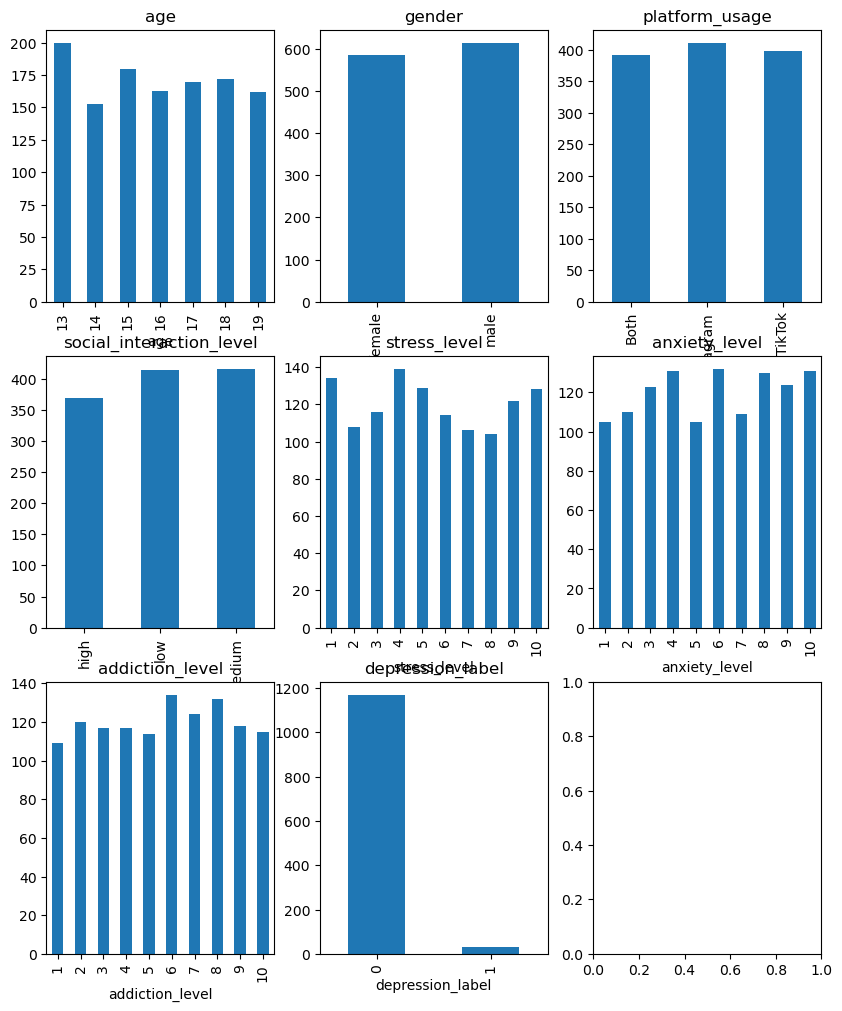

In [132]:
CategoricalCols=['age', 'gender','platform_usage','social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']
import matplotlib.pyplot as plt
fig, subplots=plt.subplots(3,3,figsize=(10,12))
subplots=subplots.flatten()
for cols , no_of_cols in zip(CategoricalCols,range(len(CategoricalCols))):
    Teen_Mental_Health_Dataset.groupby(cols).size().plot(kind='bar',ax=subplots[no_of_cols],title=cols)

### No need of imbalance treatment

## Uni Variate Analysis by Histogram

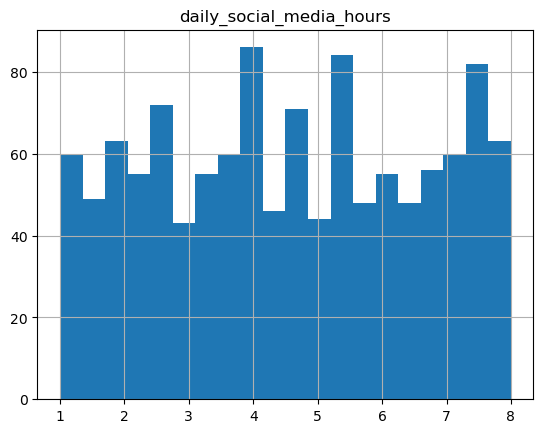

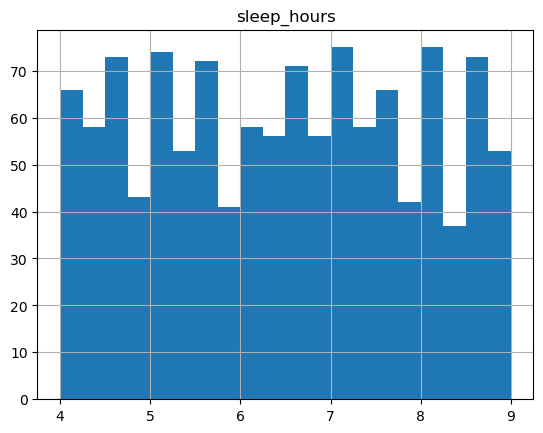

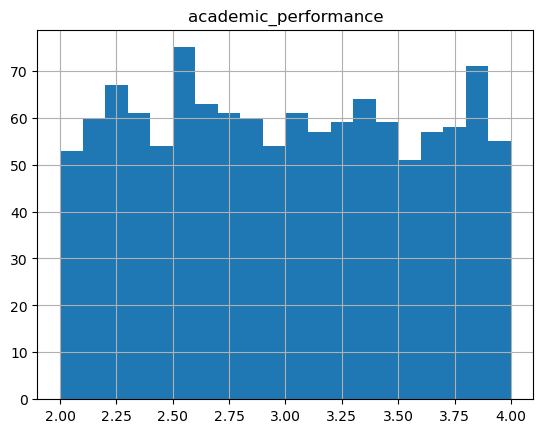

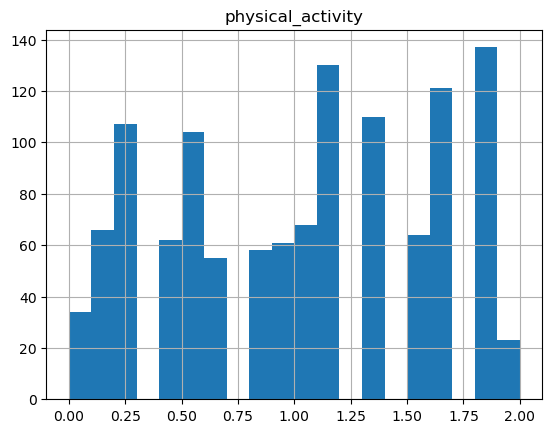

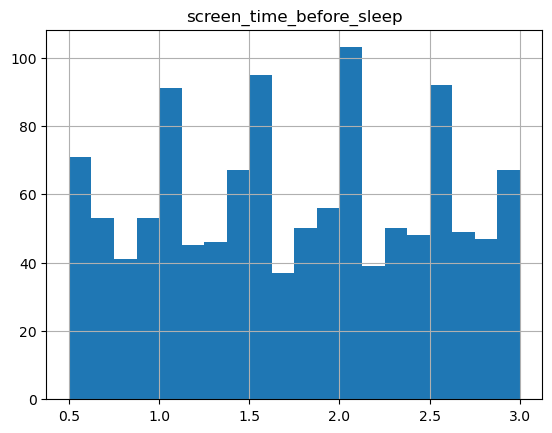

In [133]:
ContinousColumns=['daily_social_media_hours','sleep_hours','academic_performance','physical_activity','screen_time_before_sleep']
for cols in ContinousColumns:
    Teen_Mental_Health_Dataset.hist(cols,bins=20)


## No need of  Outlier Treatment

### No need of missing value treatment

In [134]:
Teen_Mental_Health_Dataset.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

## Continous Vs Categorical Bivariate Analysis by Box Plots

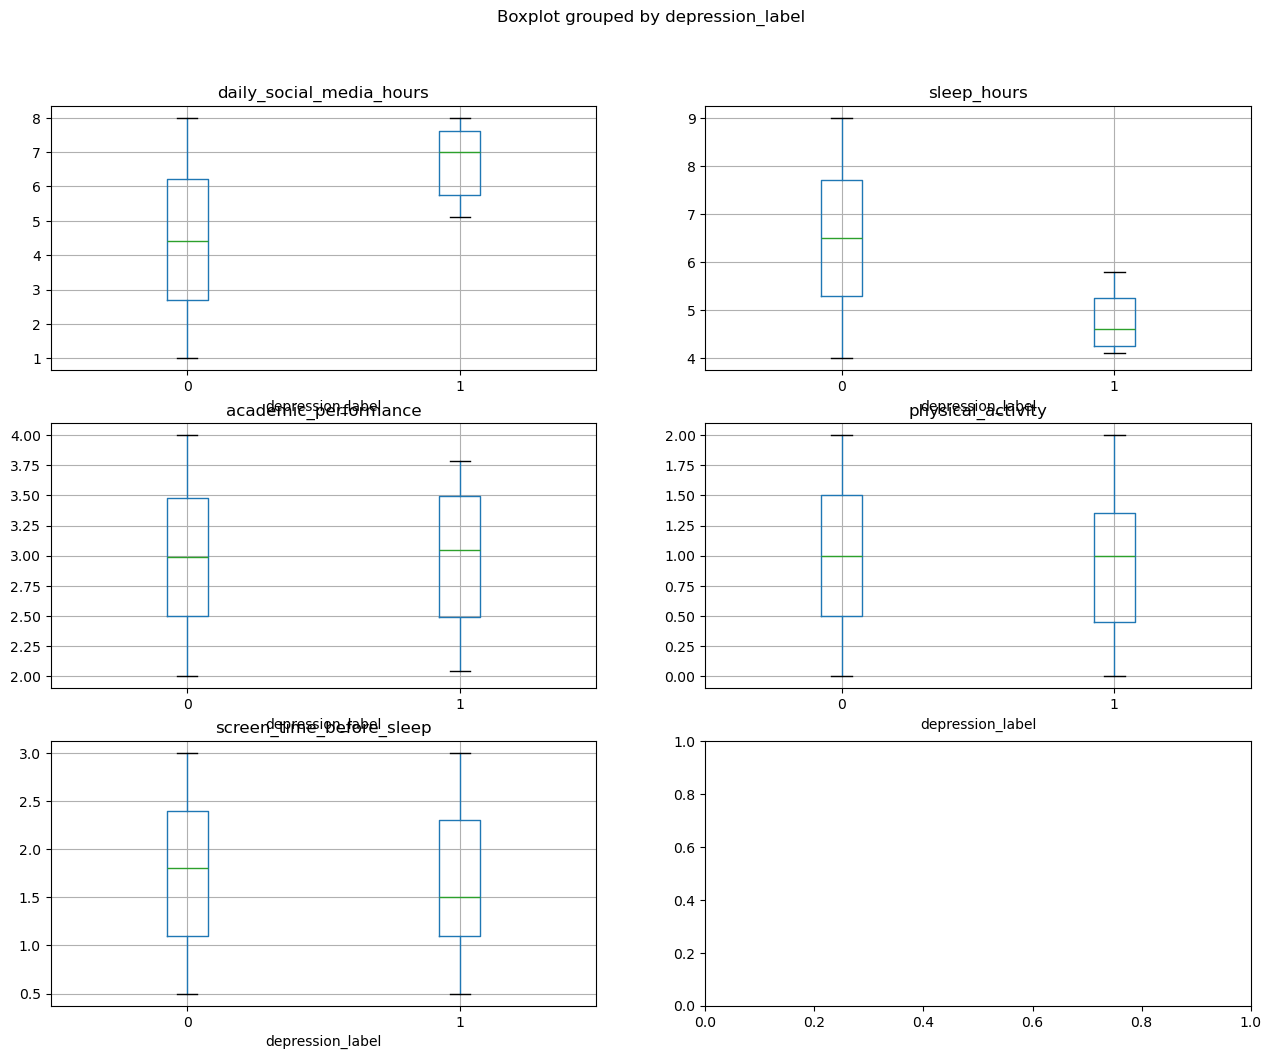

In [135]:
ContinousCols=['daily_social_media_hours','sleep_hours','academic_performance','physical_activity','screen_time_before_sleep']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(3,2,figsize=(15,12))
subplots=subplots.flatten()
for cols, no_of_cols in zip(ContinousCols,range(len(ContinousCols))):
    Teen_Mental_Health_Dataset.boxplot(column=cols,by='depression_label',vert=True,ax=subplots[no_of_cols])

## Statistical Feature Selection by Anova Function

In [136]:
ContinousCols=['daily_social_media_hours','sleep_hours','academic_performance','physical_activity','screen_time_before_sleep']
def function_anova(inpData,ContinousCols,targetVariable):
    from scipy.stats import f_oneway
    SelectedPredictors=[]
    for cols in ContinousCols:
        CategoricalGroupLists=inpData.groupby(targetVariable)[cols].apply(list)
        AnovaResults=f_oneway(*CategoricalGroupLists)
        if AnovaResults[1]<0.05:
            print(cols,' is correlated with High_Value_Order and p value is:',AnovaResults[1]) 
            SelectedPredictors.append(cols)
        else:
            print(cols,' is not correlated with High_Value_Order and p value is:',AnovaResults[1]) 
    return SelectedPredictors
function_anova(inpData=Teen_Mental_Health_Dataset,ContinousCols=['daily_social_media_hours','sleep_hours','academic_performance','physical_activity','screen_time_before_sleep'],
               targetVariable='depression_label')
  

daily_social_media_hours  is correlated with High_Value_Order and p value is: 9.95517965427216e-10
sleep_hours  is correlated with High_Value_Order and p value is: 2.778311537318552e-11
academic_performance  is not correlated with High_Value_Order and p value is: 0.9602373333059584
physical_activity  is not correlated with High_Value_Order and p value is: 0.5425155162922564
screen_time_before_sleep  is not correlated with High_Value_Order and p value is: 0.5679479490943962


['daily_social_media_hours', 'sleep_hours']

## Categorical Vs Categorical Bivariate Analysis by Grouped Bar Charts

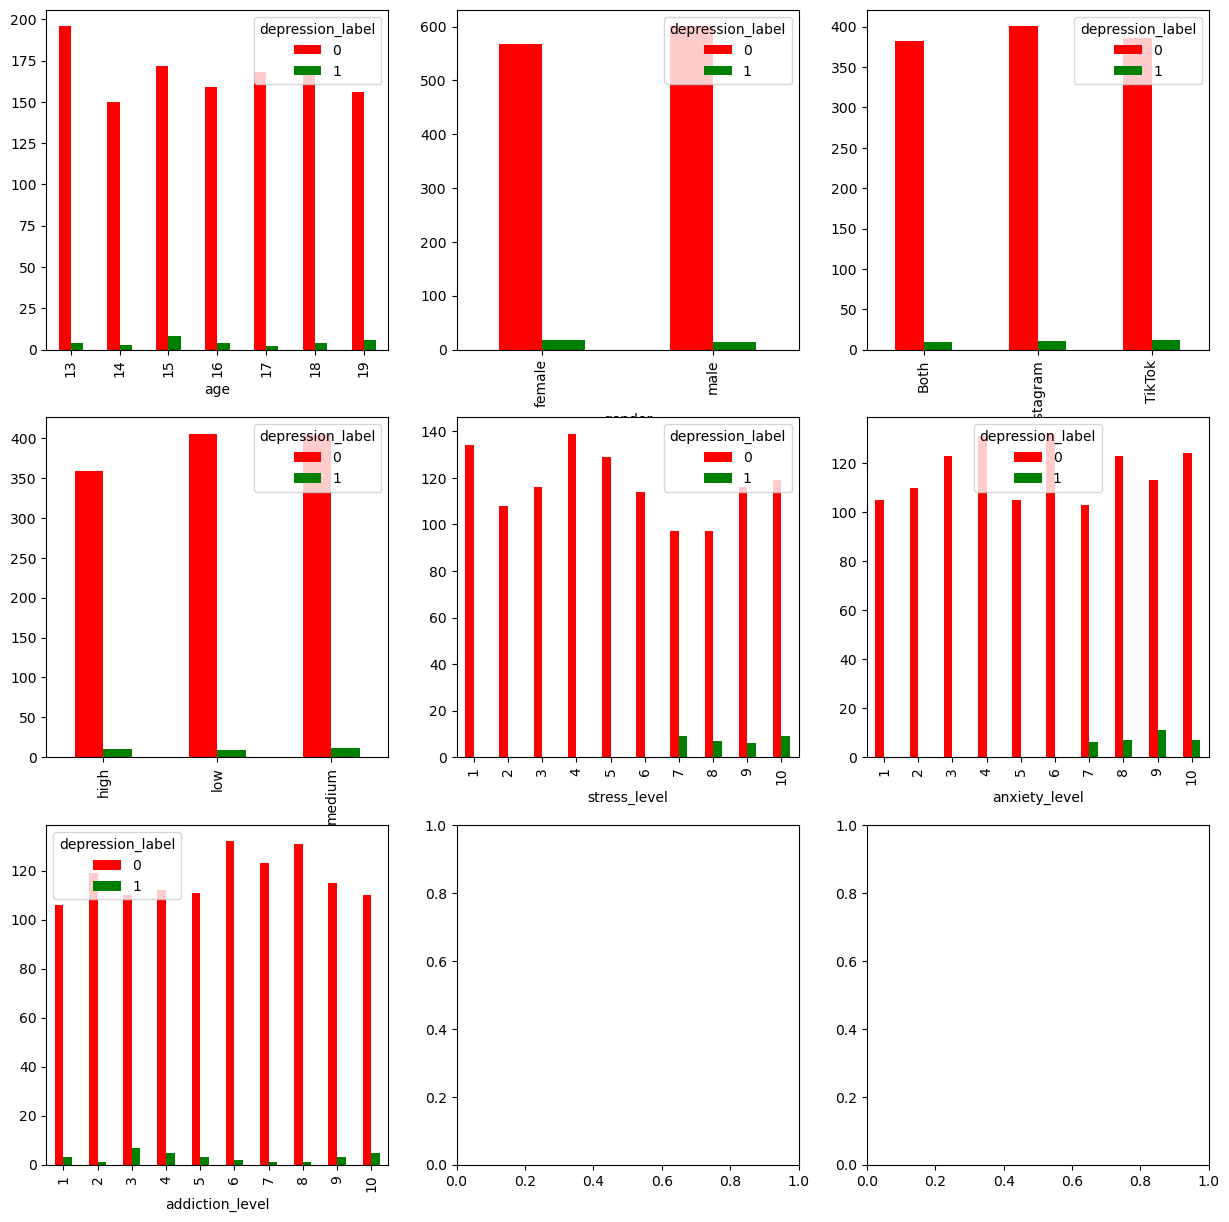

In [137]:
CategoricalCols=['age', 'gender','platform_usage','social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(3,3,figsize=(15,15))
subplots=subplots.flatten()
for cols, no_of_cols in zip(CategoricalCols,range(len(CategoricalCols))):
    crosstabresults=pd.crosstab(columns=Teen_Mental_Health_Dataset['depression_label'],index=Teen_Mental_Health_Dataset[cols])
    crosstabresults.plot.bar(color=['red','green'],ax=subplots[no_of_cols])

## Statistical Feature Selection by Chi2 Function

In [138]:
CategoricalCols=['age', 'gender','platform_usage','social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level']
def Chis2_test_function(inpData, CategoricalCols,targetVariable):
    SelectedPredictors=[]
    from scipy.stats import chi2_contingency
    for cols in CategoricalCols: 
        crosstabresults=pd.crosstab(columns=inpData[targetVariable],index=Ecommerce_Data[cols])
        chi2_results=chi2_contingency(crosstabresults)
        if chi2_results[1]<0.05:
            print(cols,' is correlated with High_Value_Order and p value is:',chi2_results[1])
            SelectedPredictors.append(cols)
        else:
            print(cols,' is not correlated with High_Value_Order and p value is:',chi2_results[1])
    return SelectedPredictors
Chis2_test_function(inpData=Teen_Mental_Health_Dataset, CategoricalCols=['age', 'gender','platform_usage','social_interaction_level', 'stress_level', 'anxiety_level', 'addiction_level'],targetVariable='depression_label')  


age  is not correlated with High_Value_Order and p value is: 0.5203410936228199
gender  is not correlated with High_Value_Order and p value is: 0.6134690795473368
platform_usage  is not correlated with High_Value_Order and p value is: 0.7965964515888357
social_interaction_level  is not correlated with High_Value_Order and p value is: 0.7956773454323949
stress_level  is correlated with High_Value_Order and p value is: 1.7793024885215333e-08
anxiety_level  is correlated with High_Value_Order and p value is: 1.1165060589178429e-07
addiction_level  is not correlated with High_Value_Order and p value is: 0.13981158105422423


['stress_level', 'anxiety_level']

## Selecting final predictors for Machine Learning

In [139]:
Teen_Mental_Health_Dataset.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='object')

In [140]:
SelectedColumns=['stress_level', 'anxiety_level','daily_social_media_hours', 'sleep_hours']

DataForML_Teen_Mental_Health_Dataset=Teen_Mental_Health_Dataset[SelectedColumns]
DataForML_Teen_Mental_Health_Dataset.to_pickle('DataForML_EcommerceData.pkl')
DataForML_Teen_Mental_Health_Dataset=pd.read_pickle('DataForML_EcommerceData.pkl')
DataForML_Teen_Mental_Health_Dataset.head()

,stress_level,anxiety_level,daily_social_media_hours,sleep_hours
0,2,2,7.9,7.4
1,8,1,1.9,8.0
2,2,4,1.3,7.6
3,1,7,7.4,6.9
4,3,5,4.7,4.9


## Data Pre-processing for Machine Learning
## Converting the nominal variable to numeric using get_dummies()

In [141]:
DataForML_Teen_Mental_Health_Dataset=pd.get_dummies(DataForML_Teen_Mental_Health_Dataset)
DataForML_Teen_Mental_Health_Dataset.head()

,stress_level,anxiety_level,daily_social_media_hours,sleep_hours
0,2,2,7.9,7.4
1,8,1,1.9,8.0
2,2,4,1.3,7.6
3,1,7,7.4,6.9
4,3,5,4.7,4.9


## No need to Convert the binary nominal variable to numeric using 1/0 mapping

In [142]:
DataForML_Teen_Mental_Health_Dataset['depression_label']=Teen_Mental_Health_Dataset['depression_label']

## Splitting the data into Training and Testing sample

In [107]:
DataForML_Teen_Mental_Health_Dataset.columns

Index(['stress_level', 'anxiety_level', 'daily_social_media_hours',
       'sleep_hours', 'depression_label'],
      dtype='object')

In [108]:
predictors=['stress_level', 'anxiety_level', 'daily_social_media_hours',
       'sleep_hours']
targetVariable= 'depression_label'
X=DataForML_Teen_Mental_Health_Dataset[predictors].values
y=DataForML_Teen_Mental_Health_Dataset[targetVariable].values 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=45,test_size=0.2)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape) 
print(y_test.shape)

(960, 4)
(960,)
(240, 4)
(240,)


In [109]:
X_train[0:5]

array([[6. , 4. , 1.7, 5.3],
       [4. , 9. , 7.4, 8.9],
       [2. , 9. , 1.6, 4.4],
       [4. , 9. , 3.8, 4.4],
       [5. , 1. , 6.4, 5.6]])

In [110]:
y_train[0:5]

array([0, 0, 0, 0, 0])

## Logistic Regression

In [111]:
from sklearn.linear_model import LogisticRegression
#'newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'
clf=LogisticRegression(C=2,penalty='l2',solver='newton-cg')
LOG=clf.fit(X_train,y_train)
prediction=LOG.predict(X_test) 
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test,prediction,average='weighted')
print('Sample Data Accuracy:',np.round((F1_Score),2)*100,'%')
from sklearn.model_selection import cross_val_score
AccuracyValues=cross_val_score(LOG,X,y,cv=5,scoring='f1_weighted')
print(AccuracyValues)
print('Final Accuracy of the Model:',np.round(np.mean(AccuracyValues),2)*100,'%')

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       229
           1       0.71      0.45      0.56        11

    accuracy                           0.97       240
   macro avg       0.84      0.72      0.77       240
weighted avg       0.96      0.97      0.96       240

[[227   2]
 [  6   5]]
Sample Data Accuracy: 96.0 %
[0.98333333 0.97994564 0.9718363  0.98545648 0.99166667]
Final Accuracy of the Model: 98.0 %


## Decision Tree

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       0.95      1.00      0.98       229
           1       0.00      0.00      0.00        11

    accuracy                           0.95       240
   macro avg       0.48      0.50      0.49       240
weighted avg       0.91      0.95      0.93       240

[[229   0]
 [ 11   0]]
Sample Data Accuaracy: 93.0 %
[0.96265823 0.96265823 0.96953867 0.96265823 0.95646582]
Final Accuracy of the Model: 96.0 %


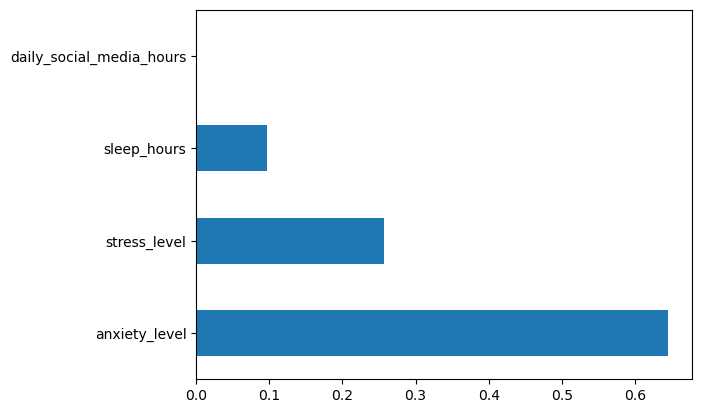

In [112]:
from sklearn.tree import DecisionTreeClassifier
clf=DecisionTreeClassifier(max_depth=3,criterion='gini')
DTree=clf.fit(X_train,y_train)
prediction=DTree.predict(X_test)
from sklearn import metrics
print(metrics.classification_report(y_test,prediction))
print(metrics.confusion_matrix(y_test,prediction))
F1_Score=metrics.f1_score(y_test,prediction,average='weighted')
print('Sample Data Accuaracy:',np.round((F1_Score),2)*100,'%')
feature_importances=pd.Series(DTree.feature_importances_,index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
from sklearn.model_selection import cross_val_score
AccuracyValues=cross_val_score(DTree,X,y,cv=5,scoring='f1_weighted')
print(AccuracyValues)
print('Final Accuracy of the Model:',np.round(np.mean(AccuracyValues),2)*100,'%')

## Random Forest Classifier

RandomForestClassifier(n_estimators=300, oob_score=True)
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       229
           1       1.00      0.55      0.71        11

    accuracy                           0.98       240
   macro avg       0.99      0.77      0.85       240
weighted avg       0.98      0.98      0.98       240

[[229   0]
 [  5   6]]


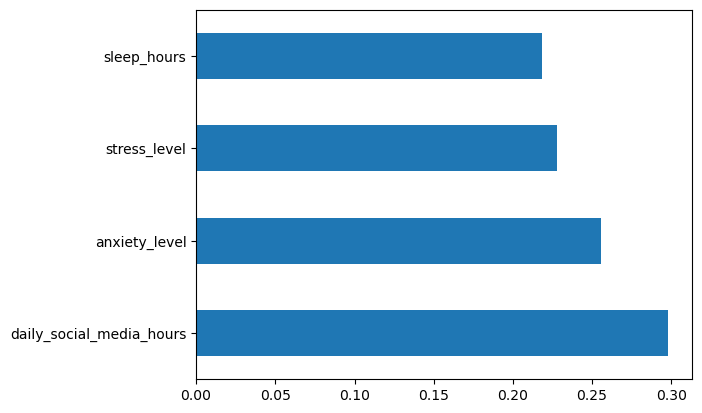

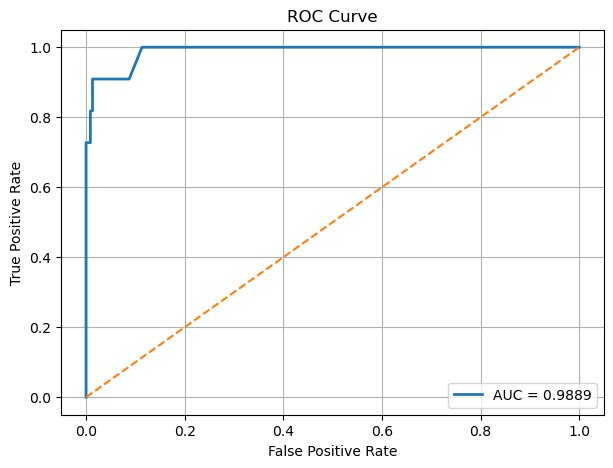

OOB Score: 99.0 %
OOB Error: 1.0 %
ROC-AUC Score: 0.9889


In [113]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=300,criterion='gini', oob_score=True)
print(clf)
 
#Creating the model on Training Data
RF=clf.fit(X_train,y_train)
prediction=RF.predict(X_test)

#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))
print(metrics.confusion_matrix(y_test, prediction)) 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(RF.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['cardio']=y_test
TestingDataResults['Prediction']=prediction
TestingDataResults.head()


from sklearn.metrics import roc_curve, roc_auc_score
y_prob = RF.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {auc:.4f}')
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()
OOBScore = RF.oob_score_
print("OOB Score:", round(OOBScore,2)*100,'%')
OOBError = 1 - OOBScore
print("OOB Error:", round(OOBError,2)*100,'%')
auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", round(auc, 4))

In [ ]:
#!pip install xgboost

In [ ]:
#import sys
#!{sys.executable} -m pip install xgboost

In [ ]:
#from xgboost import XGBClassifier

#print("XGBoost installed successfully!")

In [ ]:
#import sys
#print(sys.executable) 

In [ ]:
#import sys
#!{sys.executable} -m pip show xgboost

In [ ]:
#import sys
#print(sys.executable)

#!{sys.executable} -m pip list

## XGBoost Classifier

In [ ]:
from xgboost import XGBClassifier
clf=XGBClassifier(max_depth=4, learning_rate=0.8, n_estimators=700, objective='binary:logistic', booster='gbtree')

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.8, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=700,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       229
           1       1.00      0.73      0.84        11

    accuracy                           0.99       240
   macro avg       0.9

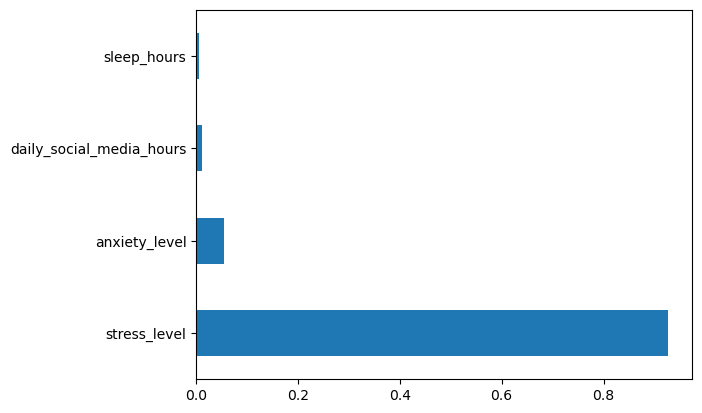

In [114]:
###### Xgboost Classification in Python ####### 
import pandas as pd 
from xgboost import XGBClassifier
clf=XGBClassifier(max_depth=4, learning_rate=0.8, n_estimators=700, objective='binary:logistic', booster='gbtree')
 
#Printing all the parameters of XGBoost
print(clf)
 
#Creating the model on Training Data                                                                                                         
XGB=clf.fit(X_train,y_train)
prediction=XGB.predict(X_test)
 
#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))
print(metrics.confusion_matrix(y_test, prediction))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(XGB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh') 
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['TargetColumn']=y_test
TestingDataResults['Prediction']=prediction   
TestingDataResults.head()
print('Final Accuracy of the Model:',round(metrics.f1_score(y_test, prediction,average='weighted'),4)*100,"%")

## Ada Boost Classifier

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.05, n_estimators=600)
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       229
           1       1.00      0.64      0.78        11

    accuracy                           0.98       240
   macro avg       0.99      0.82      0.88       240
weighted avg       0.98      0.98      0.98       240

[[229   0]
 [  4   7]]


,stress_level,anxiety_level,daily_social_media_hours,sleep_hours,TargetColumn,Prediction
0,2.0,6.0,2.5,6.8,0,0
1,1.0,7.0,6.6,8.2,0,0
2,1.0,6.0,7.1,8.4,0,0
3,8.0,3.0,7.2,6.1,0,0
4,9.0,7.0,1.5,8.7,0,0


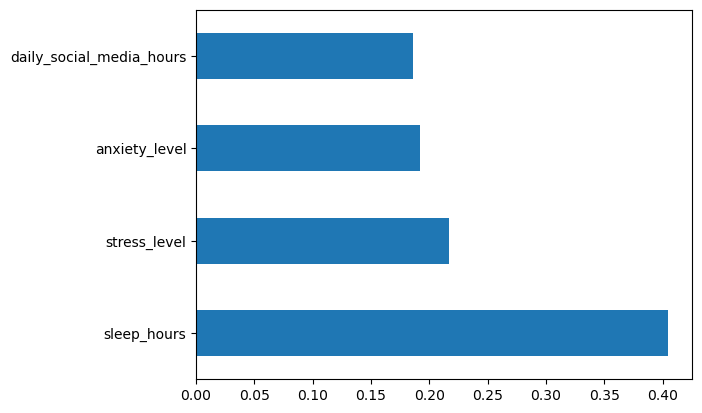

In [115]:
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
 
#Choosing Decision Tree with 1 level as the weak learner
DTC=DecisionTreeClassifier(max_depth=1)
clf = AdaBoostClassifier(n_estimators=600, estimator=DTC ,learning_rate=0.05)
 
#Printing all the parameters of Adaboost
print(clf)
 
#Creating the model on Training Data
AB=clf.fit(X_train,y_train)
prediction=AB.predict(X_test)
 
#Measuring accuracy on Testing Data
from sklearn import metrics
print(metrics.classification_report(y_test, prediction))
print(metrics.confusion_matrix(y_test, prediction))
 
#Plotting the feature importance for Top 10 most important columns
%matplotlib inline
feature_importances = pd.Series(AB.feature_importances_, index=predictors)
feature_importances.nlargest(10).plot(kind='barh')
 
#Printing some sample values of prediction
TestingDataResults=pd.DataFrame(data=X_test, columns=predictors)
TestingDataResults['TargetColumn']=y_test
TestingDataResults['Prediction']=prediction
TestingDataResults.head()

# Selected XGBoost Classification Model for Deployment

## Deploying on Sample Production Data

In [145]:
NewData = pd.DataFrame(data=[
[7,8,6.2,4.1],
[8,9,7.8,5.3],
[8,10,7.8,5.0],
[9,7,5.1,4.1],
[10,9,7.5,4.8],
[10,9,7.2,4.2],
[10,8,5.2,4.3],
[7,9,5.2,5.6],
[8,9,7.7,4.2],
[7,9,7.4,5.5],
[9,10,7.0,4.5],
[7,9,6.0,4.2],
[7,10,5.3,5.6],
[10,8,5.3,4.7],
[9,7,8.0,5.7],
[8,8,7.2,5.0],
[9,10,6.2,4.4],
[7,9,7.5,5.4],
[8,7,7.7,4.4],
[7,7,5.3,4.3],
[10,8,6.9,5.8],
[10,9,6.4,4.2],
[7,9,5.4,5.2],
[10,7,7.8,4.2],
[7,8,5.5,5.7],
[10,10,7.3,4.1],
[9,7,7.4,4.4],
[8,10,7.8,4.6],
[10,9,6.9,4.6],
[9,10,6.3,4.8]
]
,
 columns=predictors)


In [146]:
newX=NewData.values

In [147]:
XGB.predict(newX)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1])

In [148]:
def GenerateSurvialPred(inpData):
    newX=inpData.values
    # Making sure the new data is also Normalized using the same normalization PredictorScalerFit
    pred=XGB.predict(newX)
    inpData['Prediction']=pred
    return(inpData)

In [149]:
GenerateSurvialPred(inpData=NewData)

,stress_level,anxiety_level,daily_social_media_hours,sleep_hours,Prediction
0,7,8,6.2,4.1,1
1,8,9,7.8,5.3,1
2,8,10,7.8,5.0,1
3,9,7,5.1,4.1,1
4,10,9,7.5,4.8,1
5,10,9,7.2,4.2,1
6,10,8,5.2,4.3,1
7,7,9,5.2,5.6,1
8,8,9,7.7,4.2,1
9,7,9,7.4,5.5,1
